# Feature Creation

**Goal:** Generate additional data features for the prediction model

First Ideas:
1. Recent Form
2. Head-2-Head Score
3. Attacking Skill
4. Defensive Skill

In [15]:
import pandas as pd
import numpy as np
import datetime as dt
from pathlib import Path
from collections import deque

from ml_world_cup_predictor.data_transformation import transform_match_data 
from ml_world_cup_predictor.match_filtering import _generate_team_list
from ml_world_cup_predictor.feature_engineering import generate_match_features

played, _ = transform_match_data()

played.tail(15)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,shootout_id,shootout_winner,year,result,goal_diff
49418,2026-06-15,Iran,New Zealand,2.0,2.0,FIFA World Cup,Inglewood,United States,True,2026-06-15_Iran_New Zealand,NaN,2026,D,0.0
49419,2026-06-15,Spain,Cape Verde,0.0,0.0,FIFA World Cup,Atlanta,United States,True,2026-06-15_Spain_Cape Verde,NaN,2026,D,0.0
49420,2026-06-15,Saudi Arabia,Uruguay,1.0,1.0,FIFA World Cup,Miami Gardens,United States,True,2026-06-15_Saudi Arabia_Uruguay,NaN,2026,D,0.0
49421,2026-06-16,France,Senegal,3.0,1.0,FIFA World Cup,East Rutherford,United States,True,2026-06-16_France_Senegal,NaN,2026,W,2.0
49422,2026-06-16,Iraq,Norway,1.0,4.0,FIFA World Cup,Foxborough,United States,True,2026-06-16_Iraq_Norway,NaN,2026,L,3.0
49423,2026-06-16,Argentina,Algeria,3.0,0.0,FIFA World Cup,Kansas City,United States,True,2026-06-16_Argentina_Algeria,NaN,2026,W,3.0
49424,2026-06-16,Austria,Jordan,3.0,1.0,FIFA World Cup,Santa Clara,United States,True,2026-06-16_Austria_Jordan,NaN,2026,W,2.0
49425,2026-06-17,Portugal,DR Congo,1.0,1.0,FIFA World Cup,Houston,United States,True,2026-06-17_Portugal_DR Congo,NaN,2026,D,0.0
49426,2026-06-17,Uzbekistan,Colombia,1.0,3.0,FIFA World Cup,Mexico City,Mexico,True,2026-06-17_Uzbekistan_Colombia,NaN,2026,L,2.0
49427,2026-06-17,England,Croatia,4.0,2.0,FIFA World Cup,Arlington,United States,True,2026-06-17_England_Croatia,NaN,2026,W,2.0


## Team Form

Form will be based on the previous 5 games, using a standard points format:
- Win = 3 Points
- Draw = 1 Point
- Loss = 0 Points

Maximum Points = 15

Form Index = Total Earned Point / 15

In [16]:
# Use a queue of past games 

teams = _generate_team_list(played)
form = {team:deque(maxlen = 5) for team in teams}
form_history = []

for row in played.itertuples(index = True,name='match'):

    form_history.append({'date':row.date,
                         **{team:sum(form_list)/((3*len(form_list)) if form_list else np.nan)
                            for team,form_list in form.items() if team in [row.home_team,row.away_team]}})


    home_result = 3 if row.result == 'W' else 0 if row.result == 'L' else 1
    away_result = 3 if row.result == 'L' else 0 if row.result == 'W' else 1

    form[row.home_team].append(home_result)
    form[row.away_team].append(away_result)

    

form_df = pd.DataFrame(form_history)
form_df = form_df[~form_df.index.duplicated(keep='last')]
form_df = form_df.ffill()



In [17]:

form_df.head(20)


,date,England,Scotland,Wales,Northern Ireland,Canada,United States,Argentina,Uruguay,Austria,...,West Papua,Elba Island,Yoruba Nation,Biafra,Mapuche,Maule Sur,Aymara,Ticino,Hmong,Marshall Islands
0,1872-11-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1873-03-08,0.333333,0.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1874-03-07,0.666667,0.166667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1875-03-06,0.444444,0.444444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1876-03-04,0.416667,0.416667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1876-03-25,0.416667,0.533333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1877-03-03,0.333333,0.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1877-03-05,0.333333,0.866667,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1878-03-02,0.266667,0.866667,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1878-03-23,0.266667,1.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Head-to-Head Scores

Investigate the size of match-ups to see if enough data is available to warant building a Head-to_Head feature

In [18]:
pairs = np.sort(played[['home_team','away_team']].values,axis=1)
pairs = pd.Series(list(map(tuple,pairs)))

count = pairs.value_counts()

print(f'Total Matchups = {len(count):,}')
print(f'Matchups with more than 50 occurences = {len(count[count >=50]):,}')
print(f'Matchups with less than 15 occurences = {len(count[count <15]):,}')


Total Matchups = 7,524
Matchups with more than 50 occurences = 81
Matchups with less than 15 occurences = 6,722


Head to Head matches to sparse for the majority of teams. Ignoring these feature build

## Attack Skill

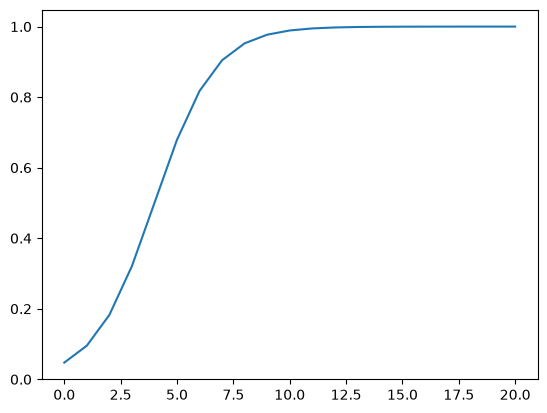

In [36]:
# Testing Attack Feature
import matplotlib.pyplot as plt


goals = np.arange(21)
attack_index = 1 / (1 + np.exp(-0.75*(goals-4)))

plt.plot(goals,attack_index)